# Variational DA with a Learned Inverse Observation Operator — PyTorch

Port of Frerix et al. 2021 ([arXiv:2102.11192](https://arxiv.org/abs/2102.11192)) from JAX/Flax to PyTorch.

**Sections**
1. Lorenz96: system, inverse-observation CNN, variational DA (obs-space / physics-space / hybrid)
2. Experiment A — 3 Gaussian noise levels on observations
3. Experiment B — Full 4D-Var (background term, obs-error covariance R, sliding window)
4. Kolmogorov Flow: pseudospectral 2D NSE, repeat the same pipeline

Designed for Colab GPU. Defaults are small enough to run in a few minutes — scale up for real experiments.

In [1]:
# Colab setup
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import sys, subprocess
def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# torchdiffeq is optional — we use a hand-written RK4 below. Uncomment if you want adaptive solvers.
# pip('torchdiffeq')

In [2]:
import math
from functools import partial
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)
print(f'device={device}, torch={torch.__version__}')

device=cuda, torch=2.10.0+cu128


### Disk cache (Google Drive)

Survives runtime resets. Set `FORCE_RETRAIN = True` to ignore the cache and regenerate. To clear: delete files in `/content/drive/MyDrive/invobs_cache/`.

In [3]:
import os

FORCE_RETRAIN = False
CACHE_DIR = '/content/drive/MyDrive/invobs_cache'

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
os.makedirs(CACHE_DIR, exist_ok=True)


def cache_path(name):
    return os.path.join(CACHE_DIR, name)


def save_cache(obj, name):
    torch.save(obj, cache_path(name))
    print(f'  [cache] wrote {name}')


def load_cache(name):
    p = cache_path(name)
    if FORCE_RETRAIN or not os.path.exists(p):
        return None
    print(f'  [cache] loaded {name}')
    return torch.load(p, map_location=device, weights_only=False)


print(f'Cache dir: {CACHE_DIR}')
print(f'Existing cache files: {sorted(os.listdir(CACHE_DIR)) if os.path.isdir(CACHE_DIR) else []}')

Mounted at /content/drive
Cache dir: /content/drive/MyDrive/invobs_cache
Existing cache files: ['kf_da_results_N8_T10.pt', 'kf_diag_cov.pt', 'kf_inverter_N1000_E100.pt', 'kf_inverter_N200_E100.pt', 'l96_4dvar_T120_W10_S4_so0.5_sb1.0.pt', 'l96_4dvar_combos_N16_T10.pt', 'l96_corr.pt', 'l96_inverter_sigma0.0.pt', 'l96_inverter_sigma0.0_n32000_ep500.pt', 'l96_inverter_sigma0.1.pt', 'l96_inverter_sigma0.5.pt', 'l96_inverter_sigma1.0.pt', 'l96_noise_results.pt', 'l96_train_data_n32000_T20_warmup1000_sigma0.0.pt', 'l96_train_data_n32000_T20_warmup1000_sigma0.1.pt']


---
## 1. Lorenz96

$\dot x_k = -x_{k-1}(x_{k-2} - x_{k+1}) - x_k + F$ with periodic BCs. Observation operator: subsample every `observe_every` grid points.

In [ ]:
def rk4_step(rhs, x, dt):
    k1 = rhs(x)
    k2 = rhs(x + 0.5 * dt * k1)
    k3 = rhs(x + 0.5 * dt * k2)
    k4 = rhs(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class Lorenz96:
    def __init__(self, grid_size=40, F=8.0, dt=0.01, observe_every=4, n_inner=10):
        # n_inner internal RK4 steps per "outer" step of size dt*n_inner.
        self.grid_size = grid_size
        self.F = F
        self.dt = dt
        self.n_inner = n_inner
        self.outer_dt = dt * n_inner
        self.observe_every = observe_every

    def rhs(self, x):
        xp1 = torch.roll(x, -1, dims=-1)
        xm1 = torch.roll(x,  1, dims=-1)
        xm2 = torch.roll(x,  2, dims=-1)
        return (xp1 - xm2) * xm1 - x + self.F

    def step(self, x):
        for _ in range(self.n_inner):
            x = rk4_step(self.rhs, x, self.dt)
        return x

    def integrate(self, x0, n_steps, start_with_input=True):
        traj = [x0] if start_with_input else []
        x = x0
        n = n_steps if start_with_input else n_steps
        for t in range(n_steps - (1 if start_with_input else 0)):
            x = self.step(x)
            traj.append(x)
        return torch.stack(traj, dim=0)  # (T, ..., grid_size)

    def warmup(self, x0, total_inner_steps):
        x = x0
        for _ in range(total_inner_steps):
            x = rk4_step(self.rhs, x, self.dt)
        return x

    def observe(self, x):
        return x[..., ::self.observe_every]


L96 = Lorenz96(grid_size=40, dt=0.01, n_inner=10, observe_every=4)  # outer_dt = 0.1

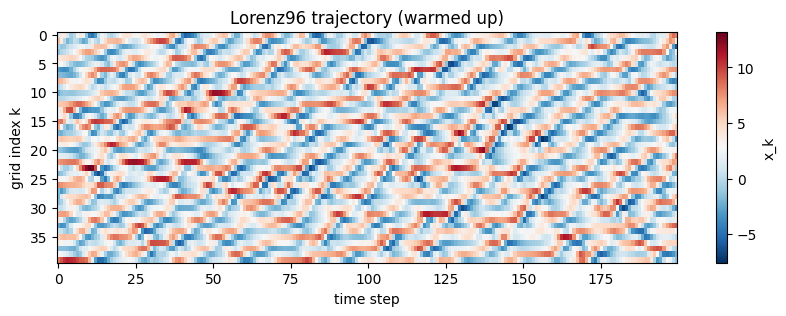

In [ ]:
# Quick sanity plot: integrate a random initial state, show a Hovmoller diagram.
x0 = torch.randn(40, device=device) * 0.5
x0 = L96.warmup(x0, total_inner_steps=2000)  # spin up to attractor
traj = L96.integrate(x0, n_steps=200)  # (200, 40)

plt.figure(figsize=(10, 3))
plt.imshow(traj.cpu().numpy().T, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='x_k')
plt.xlabel('time step'); plt.ylabel('grid index k')
plt.title('Lorenz96 trajectory (warmed up)')
plt.show()

### Data generation and spatial correlation

`generate_data` returns `(X0, X_true, Y)` where `Y = H(X_true) + noise`. Also computes a long trajectory for estimating the spatial correlation matrix `C` used to precondition the optimizer.

In [4]:
def generate_data(dyn_sys, n_samples, n_time_steps, n_warmup, obs_noise_std=0.0, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)
    X0_cold = torch.randn(n_samples, dyn_sys.grid_size, device=device, generator=g) * 0.5
    # Spin up each trajectory independently.
    X0 = torch.stack([dyn_sys.warmup(x, n_warmup) for x in X0_cold], dim=0)
    # Forward integration.
    X = torch.stack([dyn_sys.integrate(x, n_time_steps) for x in X0], dim=0)  # (N, T, grid)
    Y_clean = dyn_sys.observe(X)                                               # (N, T, obs_grid)
    noise = torch.empty_like(Y_clean).normal_(generator=g) * obs_noise_std
    Y = Y_clean + noise
    return X0, X, Y, Y_clean


def estimate_correlation(dyn_sys, n_samples=2000, n_warmup=1000, seed=1):
    # One long ensemble of warmed-up states. C is estimated over the ensemble.
    g = torch.Generator(device=device).manual_seed(seed)
    X0 = torch.randn(n_samples, dyn_sys.grid_size, device=device, generator=g) * 0.5
    X = torch.stack([dyn_sys.warmup(x, n_warmup) for x in X0], dim=0)  # (N, grid)
    X = X - X.mean(dim=0, keepdim=True)
    C = (X.T @ X) / (X.shape[0] - 1)  # (grid, grid)
    # Symmetric matrix square root via eigendecomposition.
    eigvals, eigvecs = torch.linalg.eigh(C)
    eigvals = torch.clamp(eigvals, min=1e-8)
    C_sqrt = eigvecs @ torch.diag(eigvals.sqrt()) @ eigvecs.T
    C_inv_sqrt = eigvecs @ torch.diag(eigvals.rsqrt()) @ eigvecs.T
    C_inv = eigvecs @ torch.diag(1.0 / eigvals) @ eigvecs.T
    return dict(C=C, C_sqrt=C_sqrt, C_inv_sqrt=C_inv_sqrt, C_inv=C_inv)


corr = load_cache('l96_corr.pt')
if corr is None:
    corr = estimate_correlation(L96, n_samples=1000, n_warmup=500)
    save_cache(corr, 'l96_corr.pt')
print('C shape:', corr['C'].shape, 'cond=', torch.linalg.cond(corr['C']).item())

  [cache] loaded l96_corr.pt
C shape: torch.Size([40, 40]) cond= 8.721698760986328


### Inverse observation operator $H^{-1}_\theta$

Maps an *observation sequence* $Y \in \mathbb{R}^{T \times n_{obs}}$ back to full physical space $X \in \mathbb{R}^{T \times n_{grid}}$. CNN with **periodic** padding in the grid dimension and **zero** padding in time (matches the paper's `PeriodicSpaceConv`).

In [ ]:
class PeriodicSpaceConv2d(nn.Module):
    """Conv2d over (time, space). Space gets periodic padding, time gets zero padding."""
    def __init__(self, in_ch, out_ch, k_t=3, k_x=3):
        super().__init__()
        self.k_t = k_t
        self.k_x = k_x
        # Inner conv has 'valid' behavior; we pad manually.
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=(k_t, k_x), padding=0)

    def forward(self, x):  # x: (B, C, T, X)
        pt = (self.k_t - 1) // 2
        px = (self.k_x - 1) // 2
        x = F.pad(x, (px, px, 0, 0), mode='circular')  # wrap space
        x = F.pad(x, (0, 0, pt, pt), mode='constant')  # zero time
        return self.conv(x)


class InverseObsLorenz96(nn.Module):
    def __init__(self, obs_grid=10, full_grid=40, hidden=32, n_layers=6):
        super().__init__()
        self.obs_grid = obs_grid
        self.full_grid = full_grid
        self.in_proj = PeriodicSpaceConv2d(1, hidden, 3, 3)
        self.blocks = nn.ModuleList(
            [PeriodicSpaceConv2d(hidden, hidden, 3, 3) for _ in range(n_layers)]
        )
        self.out_proj = PeriodicSpaceConv2d(hidden, 1, 3, 3)

    def forward(self, y):  # y: (B, T, obs_grid) -> (B, T, full_grid)
        B, T, _ = y.shape
        x = y.unsqueeze(1)  # (B, 1, T, obs_grid)
        # Spatial upsample with periodic-aware linear interp:
        x = F.interpolate(x, size=(T, self.full_grid), mode='bilinear', align_corners=False)
        x = F.gelu(self.in_proj(x))
        for blk in self.blocks:
            x = x + F.gelu(blk(x))
        x = self.out_proj(x)
        return x.squeeze(1)

### Train the inverse observation operator

Supervised regression: integrate trajectories, observe them, teach the net to invert $H$.

In [5]:
def train_inverter(dyn_sys, inverter, n_train=400, T_train=20, n_warmup=1000,
                   n_epochs=30, batch_size=16, lr=3e-4, obs_noise_std=0.0, log_every=5):
    # Build a dataset once.
    _, X, Y, _ = generate_data(dyn_sys, n_train, T_train, n_warmup,
                                obs_noise_std=obs_noise_std, seed=42)
    X = X.detach(); Y = Y.detach()
    opt = torch.optim.Adam(inverter.parameters(), lr=lr)
    n = X.shape[0]
    history = []
    for epoch in range(n_epochs):
        perm = torch.randperm(n, device=device)
        ep_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            y_b, x_b = Y[idx], X[idx]
            pred = inverter(y_b)
            loss = F.mse_loss(pred, x_b)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * idx.numel()
        ep_loss /= n
        history.append(ep_loss)
        if epoch % log_every == 0 or epoch == n_epochs - 1:
            print(f'  epoch {epoch:3d}  loss={ep_loss:.4f}')
    return history


inverter = InverseObsLorenz96(obs_grid=10, full_grid=40, hidden=32, n_layers=6).to(device)
ckpt = load_cache('l96_inverter_sigma0.0.pt')
if ckpt is None:
    hist = train_inverter(L96, inverter, n_train=400, T_train=20, n_epochs=500,
                          batch_size=16, obs_noise_std=0.0)
    save_cache({'state_dict': inverter.state_dict(), 'hist': hist}, 'l96_inverter_sigma0.0.pt')
else:
    inverter.load_state_dict(ckpt['state_dict'])
    hist = ckpt['hist']

plt.plot(hist); plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.title('Inverse-obs training'); plt.show()

NameError: name 'InverseObsLorenz96' is not defined

### Variational DA

Three optimization modes from the paper:
- **obs-space**: minimize $\|H(M(x_0)) - y\|^2$
- **physics-space**: minimize $\|M(x_0) - H^{-1}_\theta(y)\|^2$
- **hybrid**: physics-space warm-start → obs-space refinement

All operate in decorrelated coordinates $z = C^{-1/2} x$ (classic 4D-Var preconditioning).

In [6]:
def decorrelate(x, C_inv_sqrt):
    # x: (..., grid) -> z: (..., grid)
    return x @ C_inv_sqrt  # C is symmetric so left/right multiply is equivalent


def correlate(z, C_sqrt):
    return z @ C_sqrt


def da_loss(Z0, Y, dyn_sys, C_sqrt, T, mode, inverter=None):
    """Batched DA loss.
    Z0: (N, grid) decorrelated initial states.
    Y:  (N, T, obs_grid) observations.
    Returns scalar (mean over N samples, T steps, and obs components).
    """
    X0 = correlate(Z0, C_sqrt)           # (N, grid)
    traj = dyn_sys.integrate(X0, T)      # (T, N, grid) — rhs broadcasts over leading dims
    if mode == 'obs':
        pred = dyn_sys.observe(traj)     # (T, N, obs_grid)
        target = Y.transpose(0, 1)       # (T, N, obs_grid)
    elif mode == 'physics':
        assert inverter is not None
        inv = inverter(Y).detach()       # (N, T, grid)
        target = inv.transpose(0, 1)     # (T, N, grid)
        pred = traj
    else:
        raise ValueError(mode)
    return ((pred - target) ** 2).mean()


def lbfgs_minimize(loss_fn, z0_init, max_iter=200, history_size=20, lr=1.0):
    z = z0_init.clone().detach().requires_grad_(True)
    opt = torch.optim.LBFGS([z], max_iter=max_iter, history_size=history_size,
                            tolerance_grad=1e-12, tolerance_change=1e-12,
                            line_search_fn='strong_wolfe', lr=lr)
    history = []

    def closure():
        opt.zero_grad()
        loss = loss_fn(z)
        loss.backward()
        history.append(loss.item())
        return loss

    opt.step(closure)
    return z.detach(), history

In [7]:
def run_da(dyn_sys, inverter, corr, X0_init, Y, T,
           physics_steps=0, obs_steps=500):
    """Batched DA: all N samples optimized in a single L-BFGS call.
    X0_init: (N, grid), Y: (N, T, obs_grid). Returns X0_opt: (N, grid) and loss history."""
    C_sqrt, C_inv_sqrt = corr['C_sqrt'], corr['C_inv_sqrt']
    Z0 = decorrelate(X0_init, C_inv_sqrt)
    hist = []
    if physics_steps > 0:
        loss_p = partial(da_loss, Y=Y, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                         mode='physics', inverter=inverter)
        Z0, h1 = lbfgs_minimize(loss_p, Z0, max_iter=physics_steps)
        hist.extend(h1)
    if obs_steps > 0:
        loss_o = partial(da_loss, Y=Y, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                         mode='obs')
        Z0, h2 = lbfgs_minimize(loss_o, Z0, max_iter=obs_steps)
        hist.extend(h2)
    X0_opt = correlate(Z0, C_sqrt)
    return X0_opt, hist


def baseline_init_l96(dyn_sys, Y):
    """Batched baseline init: nearest-neighbor upsample from t=0 observations.
    Y: (N, T, obs_grid) or (T, obs_grid). Returns (N, grid) or (grid,)."""
    if Y.ndim == 3:
        return Y[:, 0].repeat_interleave(dyn_sys.observe_every, dim=-1)
    return Y[0].repeat_interleave(dyn_sys.observe_every)

### Sanity check: run DA on a single sample, all 3 modes

In [ ]:
X0_gt, X_true, Y, _ = generate_data(L96, n_samples=8, n_time_steps=10,
                                      n_warmup=500, obs_noise_std=0.0, seed=7)
sample_idx = 0
x0_gt = X0_gt[sample_idx]
y = Y[sample_idx]                      # (T, obs_grid)
Y_b = y.unsqueeze(0)                   # (1, T, obs_grid) for batched API
x0_baseline = baseline_init_l96(L96, y)                               # (grid,)
x0_invobs = inverter(Y_b).squeeze(0)[0].detach()                      # (grid,)

configs = [
    ('obs-only (baseline init)',     0,   500, x0_baseline),
    ('physics-only (baseline init)', 500, 0,   x0_baseline),
    ('hybrid (baseline init)',       200, 300, x0_baseline),
    ('obs-only (invobs init)',       0,   500, x0_invobs),
    ('hybrid (invobs init)',         200, 300, x0_invobs),
]
results = {}
for name, p_steps, o_steps, init in configs:
    X0_opt, h = run_da(L96, inverter, corr, init.unsqueeze(0), Y_b, T=y.shape[0],
                       physics_steps=p_steps, obs_steps=o_steps)
    x0_opt = X0_opt.squeeze(0)
    state_err = ((x0_opt - x0_gt) ** 2).mean().sqrt().item()
    obs_err = ((L96.observe(L96.integrate(x0_opt, y.shape[0])) - y) ** 2).mean().sqrt().item()
    results[name] = dict(x0=x0_opt.cpu(), history=h, state_rmse=state_err, obs_rmse=obs_err)
    print(f'{name:35s}  state RMSE={state_err:.4f}  obs RMSE={obs_err:.4f}')

obs-only (baseline init)             state RMSE=6.1046  obs RMSE=0.8071
physics-only (baseline init)         state RMSE=2.5532  obs RMSE=1.2426
hybrid (baseline init)               state RMSE=2.2430  obs RMSE=0.4059
obs-only (invobs init)               state RMSE=1.9312  obs RMSE=0.5042
hybrid (invobs init)                 state RMSE=2.2451  obs RMSE=0.4060


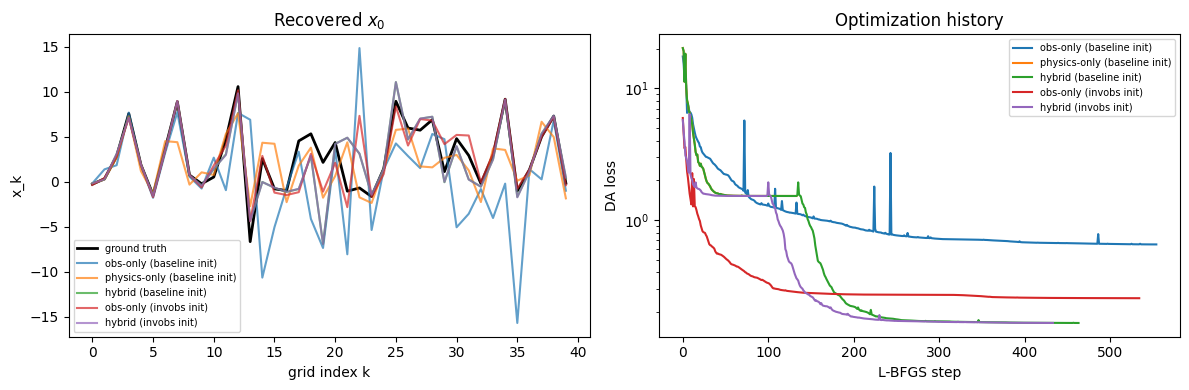

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x0_gt.cpu().numpy(), 'k-', lw=2, label='ground truth')
for name, r in results.items():
    ax[0].plot(r['x0'].numpy(), alpha=0.7, label=name)
ax[0].set_xlabel('grid index k'); ax[0].set_ylabel('x_k'); ax[0].legend(fontsize=7)
ax[0].set_title('Recovered $x_0$')
for name, r in results.items():
    ax[1].plot(r['history'], label=name)
ax[1].set_yscale('log'); ax[1].set_xlabel('L-BFGS step'); ax[1].set_ylabel('DA loss')
ax[1].legend(fontsize=7); ax[1].set_title('Optimization history')
plt.tight_layout(); plt.show()

---
## 2. Experiment A — 3 levels of Gaussian observation noise

We add $\mathcal{N}(0, \sigma_{obs}^2)$ noise at three levels and compare all DA modes. Retrain the inverter at each noise level — training on noisy observations is important so the learned inverse matches the test-time distribution.

In [ ]:
NOISE_LEVELS = [0.1, 0.5, 1.0]  # σ_obs
N_EVAL = 16  # number of test trajectories per noise level
T_EVAL = 10

noise_results = {s: {} for s in NOISE_LEVELS}
inverters_by_noise = {}

for sigma in NOISE_LEVELS:
    print(f'\n=== σ_obs = {sigma} ===')
    # Train a dedicated inverter so physics-space DA has a matching H^{-1}_θ.
    inv_sigma = InverseObsLorenz96(obs_grid=10, full_grid=40, hidden=32, n_layers=6).to(device)
    ckpt_name = f'l96_inverter_sigma{sigma}.pt'
    ckpt = load_cache(ckpt_name)
    if ckpt is None:
        _ = train_inverter(L96, inv_sigma, n_train=400, T_train=20, n_epochs=500,
                           batch_size=16, obs_noise_std=sigma, log_every=10)
        save_cache({'state_dict': inv_sigma.state_dict()}, ckpt_name)
    else:
        inv_sigma.load_state_dict(ckpt['state_dict'])
    inverters_by_noise[sigma] = inv_sigma

    # Evaluation set.
    X0_gt, X_true, Y, _ = generate_data(L96, n_samples=N_EVAL, n_time_steps=T_EVAL,
                                        n_warmup=500, obs_noise_std=sigma, seed=100)

    mode_configs = {
        'obs-only': (0, 500),
        'physics-only': (500, 0),
        'hybrid': (100, 400),
    }
    # Batched init: all N_EVAL samples at once.
    X0_init = baseline_init_l96(L96, Y)  # (N_EVAL, grid)
    for mode_name, (p_steps, o_steps) in mode_configs.items():
        import time; t0 = time.time()
        X0_opt, _ = run_da(L96, inv_sigma, corr, X0_init, Y, T=T_EVAL,
                           physics_steps=p_steps, obs_steps=o_steps)
        rmses = ((X0_opt - X0_gt) ** 2).mean(dim=-1).sqrt().detach().cpu().numpy()
        noise_results[sigma][mode_name] = rmses
        print(f'  {mode_name:15s}  state RMSE = {rmses.mean():.4f} ± {rmses.std():.4f}'
              f'   ({time.time()-t0:.1f}s)')

save_cache(noise_results, 'l96_noise_results.pt')


=== σ_obs = 0.1 ===
  [cache] loaded l96_inverter_sigma0.1.pt
  obs-only         state RMSE = 4.9344 ± 0.6547   (75.6s)
  physics-only     state RMSE = 2.4067 ± 0.4920   (39.4s)
  hybrid           state RMSE = 2.9300 ± 1.4986   (67.8s)

=== σ_obs = 0.5 ===
  [cache] loaded l96_inverter_sigma0.5.pt
  obs-only         state RMSE = 5.1608 ± 0.7620   (68.8s)
  physics-only     state RMSE = 2.3975 ± 0.5146   (35.7s)
  hybrid           state RMSE = 2.0851 ± 1.1518   (64.8s)

=== σ_obs = 1.0 ===
  [cache] loaded l96_inverter_sigma1.0.pt
  obs-only         state RMSE = 5.2850 ± 0.7829   (65.4s)
  physics-only     state RMSE = 2.5347 ± 0.4333   (34.1s)
  hybrid           state RMSE = 2.9036 ± 1.4062   (64.8s)
  [cache] wrote l96_noise_results.pt


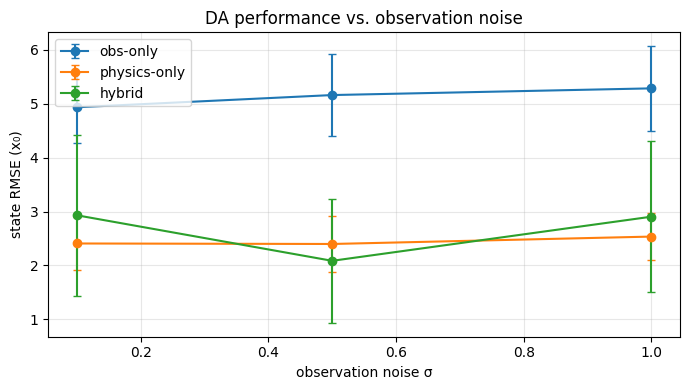

In [ ]:
# Plot: state RMSE vs noise level for each DA mode
fig, ax = plt.subplots(figsize=(7, 4))
modes = ['obs-only', 'physics-only', 'hybrid']
for mode in modes:
    means = [noise_results[s][mode].mean() for s in NOISE_LEVELS]
    stds = [noise_results[s][mode].std() for s in NOISE_LEVELS]
    ax.errorbar(NOISE_LEVELS, means, yerr=stds, marker='o', label=mode, capsize=3)
ax.set_xlabel('observation noise σ'); ax.set_ylabel('state RMSE (x₀)')
ax.set_title('DA performance vs. observation noise')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 3. Experiment B — Full 4D-Var

Standard strong-constraint 4D-Var cost:

$$ J(x_0) = \tfrac{1}{2}(x_0 - x_b)^\top B^{-1} (x_0 - x_b) + \tfrac{1}{2} \sum_{t=1}^{T} (y_t - H M_t x_0)^\top R^{-1} (y_t - H M_t x_0) $$

**Ingredients**
- $B$: background error covariance. We use the climatological $C$ scaled by $\sigma_b^2$.
- $R$: observation error covariance. Diagonal, $\sigma_{obs}^2 I$ assuming uncorrelated noise.
- $x_b$: background state, initialized from the previous cycle's analysis (sliding window).

**Sliding window / cycling.** Given a long stream of observations, we slide an assimilation window forward by `stride` steps at a time. At cycle $k$: optimize $x_0^{(k)}$ against $y_{k \cdot s : k \cdot s + T}$ starting from $x_b^{(k)} = M_s(x_0^{(k-1)})$ (the previous analysis advanced forward).

In [8]:
def var4d_cost(z0, y, dyn_sys, C_sqrt, T, z_b, R_inv_diag, B_inv_precond,
               sigma_b=1.0):
    """
    Full 4D-Var in decorrelated coordinates.

    With z = C^{-1/2} x and B = σ_b^2 C, the background term simplifies to
        (1/(2 σ_b^2)) * ||z - z_b||_2^2
    which is why z-space is a natural preconditioner.

    R_inv_diag: (obs_grid,) per-component inverse variances (diagonal R).
    """
    x0 = correlate(z0, C_sqrt)
    traj = dyn_sys.integrate(x0, T)
    y_pred = dyn_sys.observe(traj)          # (T, obs_grid)
    innov = y_pred - y                      # (T, obs_grid)

    J_o = 0.5 * (innov.pow(2) * R_inv_diag).sum()
    J_b = 0.5 * ((z0 - z_b).pow(2)).sum() / (sigma_b ** 2)
    return J_b + J_o


def run_4dvar_single(dyn_sys, corr, y, z_b, T, R_inv_diag, sigma_b, max_iter=500):
    C_sqrt, C_inv_sqrt = corr['C_sqrt'], corr['C_inv_sqrt']
    loss = partial(var4d_cost, y=y, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                   z_b=z_b, R_inv_diag=R_inv_diag, B_inv_precond=None, sigma_b=sigma_b)
    z0_init = z_b.clone()
    z_opt, hist = lbfgs_minimize(loss, z0_init, max_iter=max_iter)
    x_opt = correlate(z_opt, C_sqrt)
    return x_opt, z_opt, hist


def run_4dvar_sliding(dyn_sys, corr, Y_long, T_window, stride,
                      x_b_init, sigma_obs, sigma_b, max_iter=300):
    """
    Y_long: (T_total, obs_grid) — a single long observation stream.
    Slides a window of length T_window forward by `stride` steps per cycle.
    Returns a list of analyses x_a at each cycle start and their absolute times.
    """
    C_inv_sqrt = corr['C_inv_sqrt']
    T_total = Y_long.shape[0]
    R_inv_diag = torch.full((dyn_sys.grid_size // dyn_sys.observe_every,),
                            1.0 / (sigma_obs ** 2), device=device)
    analyses = []
    times = []
    x_b = x_b_init
    z_b = decorrelate(x_b, C_inv_sqrt)
    cycle = 0
    start = 0
    while start + T_window <= T_total:
        y_window = Y_long[start:start + T_window]
        x_a, z_a, hist = run_4dvar_single(dyn_sys, corr, y_window, z_b,
                                          T_window, R_inv_diag, sigma_b, max_iter=max_iter)
        analyses.append(x_a.detach())
        times.append(start)
        # Advance background: integrate the analysis forward by `stride` outer steps.
        x_b = dyn_sys.integrate(x_a.detach(), stride + 1)[-1]
        z_b = decorrelate(x_b, C_inv_sqrt)
        start += stride
        cycle += 1
        if cycle % 5 == 0:
            print(f'  cycle {cycle:3d}  start={times[-1]:4d}  finalJ={hist[-1]:.4g}')
    return torch.stack(analyses, dim=0), torch.tensor(times)

In [9]:
# Generate one long reference trajectory + observations
SIGMA_OBS = 0.5
SIGMA_B = 1.0
T_TOTAL = 120
T_WINDOW = 10
STRIDE = 4

X0_long, X_long, Y_long, _ = generate_data(L96, n_samples=1, n_time_steps=T_TOTAL,
                                           n_warmup=500, obs_noise_std=SIGMA_OBS, seed=2025)
X_long = X_long[0]    # (T_TOTAL, 40)
Y_long = Y_long[0]    # (T_TOTAL, 10)
x0_truth = X0_long[0]

# Bad background: climatology mean (near zero after centering)
x_b_init = torch.zeros_like(x0_truth)

cache_key = f'l96_4dvar_T{T_TOTAL}_W{T_WINDOW}_S{STRIDE}_so{SIGMA_OBS}_sb{SIGMA_B}.pt'
cached = load_cache(cache_key)
if cached is None:
    print('Running sliding-window 4D-Var...')
    analyses, times = run_4dvar_sliding(L96, corr, Y_long, T_WINDOW, STRIDE,
                                        x_b_init, SIGMA_OBS, SIGMA_B, max_iter=200)
    save_cache({'analyses': analyses, 'times': times,
                'X_long': X_long, 'Y_long': Y_long}, cache_key)
else:
    analyses, times = cached['analyses'], cached['times']
    X_long, Y_long = cached['X_long'], cached['Y_long']
print(f'Got {analyses.shape[0]} analyses.')

# Evaluate: compare each analysis to the ground-truth state at that time.
X_true_at_starts = X_long[times.cpu().numpy()]                    # (n_cycles, 40)
rmse_per_cycle = ((analyses - X_true_at_starts) ** 2).mean(dim=-1).sqrt().cpu().numpy()

NameError: name 'L96' is not defined

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

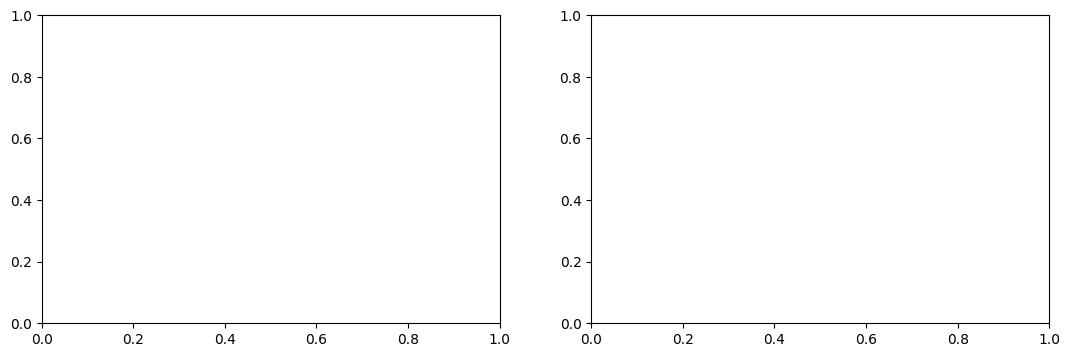

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(times.numpy(), rmse_per_cycle, 'o-')
ax[0].axhline(SIGMA_OBS, ls='--', c='gray', label='σ_obs')
ax[0].set_xlabel('window-start time step'); ax[0].set_ylabel('analysis RMSE')
ax[0].set_title('Sliding-window 4D-Var: analysis error per cycle')
ax[0].legend(); ax[0].grid(alpha=0.3)

# Hovmoller of analysis error
err = (analyses - X_true_at_starts).cpu().numpy()
im = ax[1].imshow(err.T, aspect='auto', cmap='RdBu_r',
                  vmin=-np.abs(err).max(), vmax=np.abs(err).max())
ax[1].set_xlabel('cycle'); ax[1].set_ylabel('grid index')
ax[1].set_title('Analysis error over cycles')
plt.colorbar(im, ax=ax[1]); plt.tight_layout(); plt.show()

**Extensions to try:**
- Replace the diagonal $R$ with a correlated one (e.g. colored noise in the obs stream).
- Replace the climatological $B$ with an ensemble-estimated $B$ (EnVar / EnKF hybrid).
- Add the physics-space / hybrid loss term alongside the 4D-Var cost to incorporate the learned inverse operator.
- Weak-constraint 4D-Var: add model-error terms inside the window.

---
## 4. Kolmogorov Flow

2D incompressible Navier–Stokes with Kolmogorov forcing $F = \sin(kx)\hat y - 0.1 u$.
Pseudospectral vorticity–streamfunction formulation on a doubly-periodic $[0, 2\pi]^2$ domain.

$$ \partial_t \omega + (u \cdot \nabla)\omega = \nu \nabla^2 \omega + \text{curl}(F) $$

$\omega = \nabla \times u$, $\psi$ satisfies $\nabla^2 \psi = -\omega$, $u = (\partial_y \psi, -\partial_x \psi)$.

In [10]:
class KolmogorovFlow:
    def __init__(self, N=64, L=2 * math.pi, nu=1e-3, k_forcing=4, dt=0.01,
                 n_inner=10, observe_every=4, damp=0.1):
        self.N = N
        self.L = L
        self.nu = nu
        self.k_forcing = k_forcing
        self.dt = dt
        self.n_inner = n_inner
        self.outer_dt = dt * n_inner
        self.observe_every = observe_every
        self.damp = damp

        # Wavenumbers.
        kx = torch.fft.fftfreq(N, d=L / N) * 2 * math.pi
        ky = torch.fft.fftfreq(N, d=L / N) * 2 * math.pi
        self.kx, self.ky = torch.meshgrid(kx, ky, indexing='ij')
        self.kx = self.kx.to(device); self.ky = self.ky.to(device)
        self.k2 = self.kx ** 2 + self.ky ** 2
        self.k2_nozero = self.k2.clone()
        self.k2_nozero[0, 0] = 1.0  # avoid division by zero
        # 2/3-rule dealiasing mask
        kmax = N // 3
        mask = (self.kx.abs() <= kmax * (2 * math.pi / L)) & \
               (self.ky.abs() <= kmax * (2 * math.pi / L))
        self.dealias = mask.to(device).float()

        # Forcing: F = sin(k_f * x) ĵ  -> curl(F) in 2D = -k_f cos(k_f x)
        x_grid = torch.linspace(0, L, N + 1, device=device)[:-1]
        X, _ = torch.meshgrid(x_grid, x_grid, indexing='ij')
        curl_F = -k_forcing * torch.cos(k_forcing * X)
        self.curl_F_hat = torch.fft.fft2(curl_F)

    @property
    def grid_size(self):
        return self.N

    def omega_to_uv(self, omega_hat):
        psi_hat = -omega_hat / self.k2_nozero
        psi_hat[..., 0, 0] = 0
        u_hat = 1j * self.ky * psi_hat
        v_hat = -1j * self.kx * psi_hat
        return torch.fft.ifft2(u_hat).real, torch.fft.ifft2(v_hat).real

    def rhs(self, omega_hat):
        # Nonlinear term in physical space (pseudospectral), dealiased.
        u, v = self.omega_to_uv(omega_hat)
        omega = torch.fft.ifft2(omega_hat).real
        omega_x = torch.fft.ifft2(1j * self.kx * omega_hat).real
        omega_y = torch.fft.ifft2(1j * self.ky * omega_hat).real
        adv = u * omega_x + v * omega_y
        adv_hat = torch.fft.fft2(adv) * self.dealias
        diff_hat = -self.nu * self.k2 * omega_hat
        damp_hat = -self.damp * omega_hat
        return -adv_hat + diff_hat + damp_hat + self.curl_F_hat

    def step(self, omega_hat):
        # ETD / IMEX would be better; RK4 in spectral space is fine for moderate ν.
        for _ in range(self.n_inner):
            k1 = self.rhs(omega_hat)
            k2 = self.rhs(omega_hat + 0.5 * self.dt * k1)
            k3 = self.rhs(omega_hat + 0.5 * self.dt * k2)
            k4 = self.rhs(omega_hat + self.dt * k3)
            omega_hat = omega_hat + (self.dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        return omega_hat

    def integrate(self, omega0, n_steps, start_with_input=True):
        # Accepts omega in physical space (..., N, N); returns (T, ..., N, N).
        omega_hat = torch.fft.fft2(omega0)
        traj = [omega0] if start_with_input else []
        for t in range(n_steps - (1 if start_with_input else 0)):
            omega_hat = self.step(omega_hat)
            traj.append(torch.fft.ifft2(omega_hat).real)
        return torch.stack(traj, dim=0)

    def warmup(self, omega0, total_inner_steps):
        omega_hat = torch.fft.fft2(omega0)
        saved = self.n_inner
        self.n_inner = total_inner_steps
        omega_hat = self.step(omega_hat)
        self.n_inner = saved
        return torch.fft.ifft2(omega_hat).real

    def observe(self, omega):
        return omega[..., ::self.observe_every, ::self.observe_every]


KF = KolmogorovFlow(N=64, nu=1e-3, k_forcing=4, dt=0.005, n_inner=20, observe_every=4)

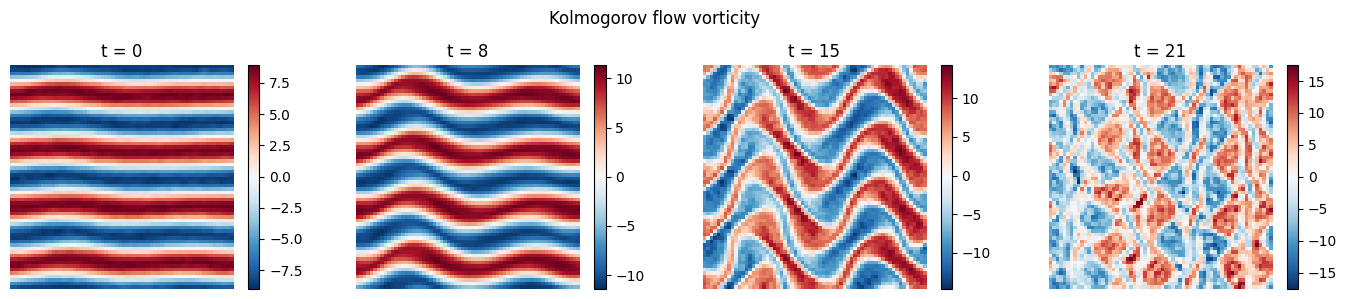

In [11]:
# Quick sanity check: spin up a random vorticity field, verify it stays bounded.
omega0 = torch.randn(KF.N, KF.N, device=device) * 0.5
omega_hat0 = torch.fft.fft2(omega0) * KF.dealias
omega0 = torch.fft.ifft2(omega_hat0).real
omega0 = KF.warmup(omega0, total_inner_steps=500)

traj = KF.integrate(omega0, n_steps=100)
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, k in enumerate([0, 8, 15, 21]):
    im = axes[i].imshow(traj[k].cpu().numpy(), cmap='RdBu_r')
    axes[i].set_title(f't = {k}'); axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.suptitle('Kolmogorov flow vorticity'); plt.tight_layout(); plt.show()

### Kolmogorov: inverse-obs CNN + DA pipeline

The same PyTorch pipeline generalizes to 2D. Below is a scaffold — swap `L96` for `KF` and adapt shapes. Training and long-window DA on Kolmogorov are **expensive** (the paper quotes ~10h on a V100); start with small $N$, short windows, and few training samples.

In [12]:
class InverseObsKolmogorov(nn.Module):
    """Per-frame 2D CNN with circular padding. Inputs: (B, T, H_obs, W_obs)."""
    def __init__(self, obs_size=16, full_size=64, hidden=32, n_layers=5):
        super().__init__()
        self.obs_size = obs_size
        self.full_size = full_size
        self.in_proj = self._make_conv(1, hidden)
        self.blocks = nn.ModuleList([self._make_conv(hidden, hidden) for _ in range(n_layers)])
        self.out_proj = self._make_conv(hidden, 1)

    @staticmethod
    def _make_conv(i, o):
        return nn.Conv2d(i, o, kernel_size=3, padding=1, padding_mode='circular')

    def forward(self, y):  # (B, T, H_obs, W_obs)
        B, T, Ho, Wo = y.shape
        x = y.reshape(B * T, 1, Ho, Wo)
        x = F.interpolate(x, size=(self.full_size, self.full_size), mode='bilinear', align_corners=False)
        x = F.gelu(self.in_proj(x))
        for blk in self.blocks:
            x = x + F.gelu(blk(x))
        x = self.out_proj(x)
        return x.reshape(B, T, self.full_size, self.full_size)


# Generate a small Kolmogorov DA dataset
def generate_data_kolmogorov(kf, n_samples, n_time_steps, n_warmup_inner=750,
                             obs_noise_std=0.0, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)
    omega0 = torch.randn(n_samples, kf.N, kf.N, device=device, generator=g) * 0.5
    omega0 = torch.stack([kf.warmup(o, n_warmup_inner) for o in omega0], dim=0)
    X = torch.stack([kf.integrate(o, n_time_steps) for o in omega0], dim=0)  # (N, T, H, W)
    Y_clean = kf.observe(X)
    Y = Y_clean + torch.empty_like(Y_clean).normal_(generator=g) * obs_noise_std
    return omega0, X, Y, Y_clean


# Optional: uncomment to train and run Kolmogorov DA. Expensive — enable only on GPU.
# kf_inv = InverseObsKolmogorov(obs_size=16, full_size=64, hidden=32, n_layers=5).to(device)
# O0, X_kf, Y_kf, _ = generate_data_kolmogorov(KF, n_samples=32, n_time_steps=8, obs_noise_std=0.1)
# ... mirror the Lorenz96 training loop here ...

**Next steps for your project**

1. Run Section 2 (Experiment A) — verify that obs-only DA degrades cleanly as σ grows and that hybrid mode (with a *well-matched* inverter) maintains quality.
2. In Section 3 (Experiment B), try correlated obs noise (e.g. AR(1) in space) so $R$ is no longer diagonal — compute $R^{-1}$ once, update `var4d_cost` to use full quadratic form $\text{innov}^\top R^{-1} \text{innov}$.
3. Combine the learned inverse operator with 4D-Var by adding a physics-space regularizer: $J \leftarrow J + \lambda \|M(x_0) - H^{-1}_\theta(y)\|^2$. This bridges the paper to classical 4D-Var.
4. For Kolmogorov, watch memory: autograd through long pseudospectral integrations is expensive. Use gradient checkpointing (`torch.utils.checkpoint`) inside `integrate` if you hit OOM.

---
## 4. Kolmogorov Flow — Inverse Observation Operator + Variational DA

2D incompressible Navier–Stokes with Kolmogorov forcing on $[0,2\pi]^2$.
We follow Section 5.2 of Frerix et al. (2021).

**Key differences from Lorenz96:**
- State is a $64 \times 64$ vorticity field (4096 dimensions).
- Observation operator subsamples every 16th grid point → $4 \times 4 = 16$ observations.
- Baseline initialisation: bicubic interpolation of the $4 \times 4$ observations.
- Error metric: mean relative $L_1$ error (same as paper's Figure 7).
- Whitening uses a diagonal (per-pixel variance) approximation of $C$  
  (full $4096 \times 4096$ covariance is too expensive for a laptop).

**Scaled-down defaults** (runs in ~10–20 min on a Colab GPU):  
`N_TRAIN_KF = 200`, `N_EPOCHS_KF = 60`.  
Set `N_TRAIN_KF = 32000`, `N_EPOCHS_KF = 500` to match the paper exactly.

### 4.1 System configuration

We configure KolmogorovFlow to match the paper: $64\times64$ grid, $\nu=10^{-3}$,  
wavenumber $k=4$, outer time step $\Delta t = 0.18$ (25 inner RK4 steps of $0.0072$),  
and observe every 16th grid point.

In [13]:
# Paper-matching KF: outer_dt = 0.0072 * 25 = 0.18
KF_PAPER = KolmogorovFlow(
    N=64, nu=1e-3, k_forcing=4,
    dt=0.0072, n_inner=25,
    observe_every=16,   # 64/16 = 4  ->  4x4 = 16 observations per snapshot
    damp=0.1,
)
print(f'KF outer_dt = {KF_PAPER.outer_dt:.4f}  (paper: ~0.18)')
print(f'Observation grid: {64 // KF_PAPER.observe_every} x {64 // KF_PAPER.observe_every}'
      f' = {(64 // KF_PAPER.observe_every)**2} points')
print(f'State dimension: {KF_PAPER.N ** 2}')

KF outer_dt = 0.1800  (paper: ~0.18)
Observation grid: 4 x 4 = 16 points
State dimension: 4096


KF outer_dt = 0.1800
Observation grid: 4 x 4
Observation grid shape: torch.Size([4, 4])
Obs values range: [-6.443, 7.902]
Obs std: 5.187


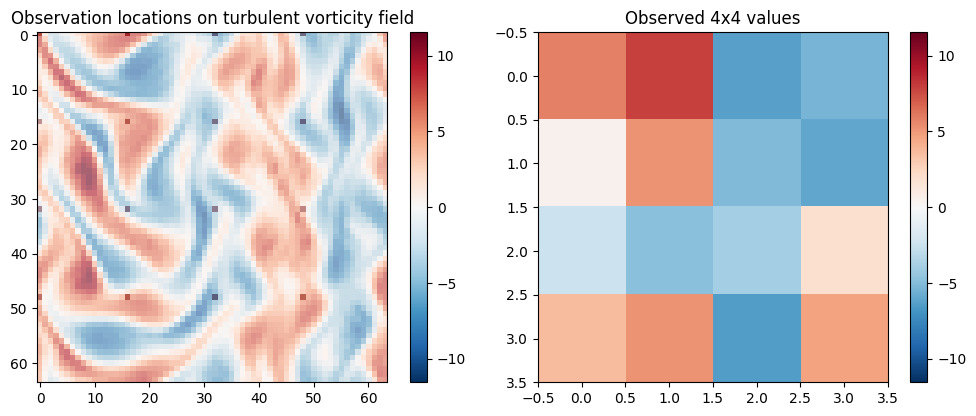

In [14]:
class KolmogorovFlowOffsetObs(KolmogorovFlow):
    """KF with offset observation sampling to avoid aliasing with stripe pattern."""
    def __init__(self, *args, obs_offset=4, **kwargs):
        super().__init__(*args, **kwargs)
        self.obs_offset = obs_offset

    def observe(self, x):
        # x: (..., H, W)
        off = self.obs_offset
        ev  = self.observe_every
        return x[..., off::ev, off::ev]


# Replace KF_PAPER with the offset version
KF_PAPER = KolmogorovFlowOffsetObs(
    N=64, nu=1e-2, k_forcing=4,
    dt=0.0072, n_inner=25,
    observe_every=16,
    damp=0.1,
    obs_offset=0,   # shifts sampling by 4 grid points
)
print(f'KF outer_dt = {KF_PAPER.outer_dt:.4f}')
print(f'Observation grid: {64 // KF_PAPER.observe_every} x {64 // KF_PAPER.observe_every}')

# Verify offset observation locations before generating any data
# Use a real warmed-up turbulent state instead of synthetic stripes
omega_diag = torch.randn(64, 64, device=device) * 0.5
omega_diag = KF_PAPER.warmup(omega_diag, total_inner_steps=750)  # warm up to turbulent regime

# Show where observations fall
mask = torch.zeros(64, 64)
off = KF_PAPER.obs_offset
ev  = KF_PAPER.observe_every
mask[off::ev, off::ev] = 1.0

obs_values = KF_PAPER.observe(omega_diag)
print(f'Observation grid shape: {obs_values.shape}')
print(f'Obs values range: [{obs_values.min():.3f}, {obs_values.max():.3f}]')
print(f'Obs std: {obs_values.std():.3f}')  # high std = good mix of values

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = omega_diag.abs().max().item()
im0 = axes[0].imshow(omega_diag.cpu(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].imshow(mask.cpu(), cmap='Reds', alpha=0.4)
axes[0].set_title('Observation locations on turbulent vorticity field')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(obs_values.cpu(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('Observed 4x4 values')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout(); plt.show()

In [ ]:
####CACHE CLEARING!!!!!
# CLEAR_KF_CACHE = True

# if CLEAR_KF_CACHE:
#     import os
#     files_to_clear = [
#         'kf_diag_cov.pt',
#     ]
#     # Clear any kf_inverter and kf_da_results files that exist
#     for fname in os.listdir(CACHE_DIR):
#         if fname.startswith('kf_'):
#             files_to_clear.append(fname)

#     for fname in files_to_clear:
#         path = cache_path(fname)
#         if os.path.exists(path):
#             os.remove(path)
#             print(f'Removed {fname}')
#         else:
#             print(f'Not found (already clear): {fname}')

Not found (already clear): kf_diag_cov.pt


### 4.2 Data generation

Each trajectory: warm up a random vorticity field, then integrate for $T$ outer steps.
Observations are noisy subsampled vorticity values.

In [15]:
def generate_data_kf(kf, n_samples, n_time_steps, n_warmup_inner=750,
                     obs_noise_std=0.0, seed=0):
    """
    Returns:
      omega0  : (N, H, W)        warmed-up initial vorticity fields
      X       : (N, T, H, W)     full vorticity trajectories
      Y       : (N, T, Ho, Wo)   (noisy) observations
      Y_clean : (N, T, Ho, Wo)   noiseless observations
    """
    g = torch.Generator(device=device).manual_seed(seed)
    omega0_cold = torch.randn(n_samples, kf.N, kf.N, device=device, generator=g) * 0.5

    # Spin up each sample independently.
    omega0 = torch.stack([kf.warmup(o, n_warmup_inner) for o in omega0_cold], dim=0)

    # Integrate forward.
    X = torch.stack([kf.integrate(o, n_time_steps) for o in omega0], dim=0)  # (N,T,H,W)

    Y_clean = kf.observe(X)   # (N, T, Ho, Wo)
    noise   = torch.empty_like(Y_clean).normal_(generator=g) * obs_noise_std
    Y       = Y_clean + noise
    return omega0, X, Y, Y_clean


# Quick check
omega0_test, X_test, Y_test, _ = generate_data_kf(KF_PAPER, n_samples=2,
                                                    n_time_steps=4,
                                                    n_warmup_inner=750, seed=99)
print('omega0 shape:', omega0_test.shape)   # (2, 64, 64)
print('X shape     :', X_test.shape)        # (2, 4, 64, 64)
print('Y shape     :', Y_test.shape)        # (2, 4, 4, 4)
print('vorticity range: [{:.2f}, {:.2f}]'.format(X_test.min().item(), X_test.max().item()))

omega0 shape: torch.Size([2, 64, 64])
X shape     : torch.Size([2, 4, 64, 64])
Y shape     : torch.Size([2, 4, 4, 4])
vorticity range: [-12.60, 12.89]


### 4.3 Diagonal background covariance

A full $4096 \times 4096$ covariance matrix is impractical on a laptop.  
Instead we estimate the **per-pixel variance** $\sigma_k^2$ from a large ensemble  
and use $B = \text{diag}(\sigma^2)$ as a diagonal approximation.  
This still preconditions the optimizer — pixels with high natural variance  
are penalised less for deviating from the background.

  [cache] loaded kf_diag_cov.pt
Loaded KF diagonal covariance from cache.
Pixel std  — mean=4.278  min=3.779  max=4.645


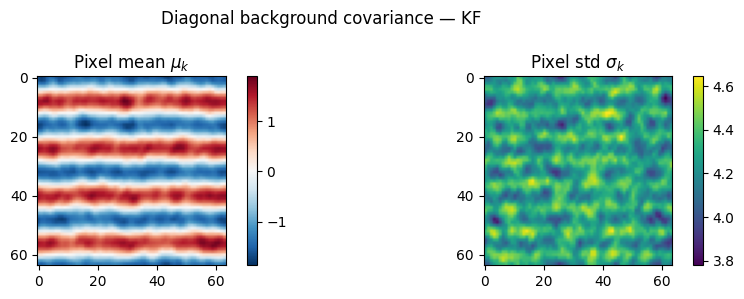

In [16]:
def estimate_diagonal_cov_kf(kf, n_samples=500, n_warmup_inner=750, seed=10):
    """Per-pixel variance over an ensemble of stationary-regime vorticity fields."""
    g = torch.Generator(device=device).manual_seed(seed)
    omega0 = torch.randn(n_samples, kf.N, kf.N, device=device, generator=g) * 0.5
    warmed = torch.stack([kf.warmup(o, n_warmup_inner) for o in omega0], dim=0)  # (N,H,W)
    mean   = warmed.mean(dim=0)                         # (H, W)
    var    = ((warmed - mean) ** 2).mean(dim=0)         # (H, W)  per-pixel variance
    var    = torch.clamp(var, min=1e-6)
    std    = var.sqrt()                                 # (H, W)
    return dict(var=var, std=std, std_inv=1.0 / std, mean=mean)


kf_corr_cache = load_cache('kf_diag_cov.pt')
if kf_corr_cache is None:
    print('Estimating KF diagonal covariance ...')
    kf_corr = estimate_diagonal_cov_kf(KF_PAPER, n_samples=500, n_warmup_inner=750)
    save_cache(kf_corr, 'kf_diag_cov.pt')
else:
    kf_corr = kf_corr_cache
    print('Loaded KF diagonal covariance from cache.')

print(f'Pixel std  — mean={kf_corr["std"].mean():.3f}  '
      f'min={kf_corr["std"].min():.3f}  max={kf_corr["std"].max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
im0 = axes[0].imshow(kf_corr['mean'].cpu(), cmap='RdBu_r')
axes[0].set_title('Pixel mean $\\mu_k$'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(kf_corr['std'].cpu(), cmap='viridis')
axes[1].set_title('Pixel std $\\sigma_k$'); plt.colorbar(im1, ax=axes[1])
plt.suptitle('Diagonal background covariance — KF'); plt.tight_layout(); plt.show()

### 4.4 Inverse observation CNN

`InverseObsKolmogorov` maps a sequence of $4 \times 4$ observation grids  
back to the full $64 \times 64$ vorticity field.  
It mirrors the L96 architecture but uses 3-D convolutions  
(time + two spatial dimensions) with periodic padding in both spatial dimensions.

In [17]:
class PeriodicSpatialConv3d(nn.Module):
    """Conv3d over (time, x, y). Both spatial dims get circular padding; time gets zero padding."""
    def __init__(self, in_ch, out_ch, kt=3, kx=3):
        super().__init__()
        self.kt, self.kx = kt, kx
        self.conv = nn.Conv3d(in_ch, out_ch, kernel_size=(kt, kx, kx), padding=0)

    def forward(self, x):   # x: (B, C, T, H, W)
        pt = (self.kt - 1) // 2
        px = (self.kx - 1) // 2
        # Spatial: circular; time: zero
        x = F.pad(x, (px, px, px, px, 0, 0), mode='circular')
        x = F.pad(x, (0, 0, 0, 0, pt, pt), mode='constant')
        return self.conv(x)


class InverseObsKolmogorov(nn.Module):
    """
    y: (B, T, Ho, Wo) -> omega: (B, T, H, W)
    Bilinear upsample from (Ho, Wo) to (H, W), then refine with residual 3-D conv blocks.
    """
    def __init__(self, obs_size=4, full_size=64, hidden=32, n_layers=5):
        super().__init__()
        self.obs_size  = obs_size
        self.full_size = full_size
        self.in_proj   = PeriodicSpatialConv3d(1, hidden, 3, 3)
        self.blocks    = nn.ModuleList(
            [PeriodicSpatialConv3d(hidden, hidden, 3, 3) for _ in range(n_layers)])
        self.out_proj  = PeriodicSpatialConv3d(hidden, 1, 3, 3)

    def forward(self, y):   # y: (B, T, Ho, Wo)
        B, T, Ho, Wo = y.shape
        # Reshape for interpolation: treat T as batch dim
        x = y.reshape(B * T, 1, Ho, Wo)
        x = F.interpolate(x, size=(self.full_size, self.full_size),
                          mode='bilinear', align_corners=False)
        # Restore to (B, 1, T, H, W) for 3-D convs
        x = x.reshape(B, T, self.full_size, self.full_size).unsqueeze(1)
        x = F.gelu(self.in_proj(x))
        for blk in self.blocks:
            x = x + F.gelu(blk(x))
        x = self.out_proj(x)
        # Output: (B, T, H, W)
        return x.squeeze(1)


# Quick shape test
_y_dummy = torch.zeros(2, 10, 4, 4, device=device)
_kf_inv  = InverseObsKolmogorov(obs_size=4, full_size=64, hidden=16, n_layers=2).to(device)
_out     = _kf_inv(_y_dummy)
print('InverseObsKolmogorov output shape:', _out.shape)   # expect (2, 10, 64, 64)
del _y_dummy, _kf_inv, _out

InverseObsKolmogorov output shape: torch.Size([2, 10, 64, 64])


### 4.5 Training the inverse observation operator

Supervised regression on vorticity trajectories.  
The network learns: *given subsampled vorticity at 16 points over T time steps,  
reconstruct the full 64×64 vorticity field.*

> **Compute note.** The paper uses 32 000 trajectories × 500 epochs on a V100.  
> The defaults below (`N_TRAIN_KF=200`, `N_EPOCHS_KF=60`) run in ~15 min on  
> a Colab T4. Increase for better results.

  [cache] loaded kf_inverter_N1000_E100.pt
Loaded KF inverter from cache.


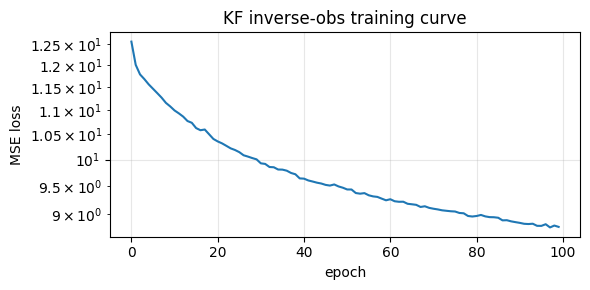

In [18]:
N_TRAIN_KF  = 1000    # paper: 32000
N_EPOCHS_KF = 100     # paper: 500
T_TRAIN_KF  = 10     # assimilation window length
BATCH_KF    = 8      # paper: 8


def train_inverter_kf(kf, inverter, n_train=N_TRAIN_KF, T_train=T_TRAIN_KF,
                      n_epochs=N_EPOCHS_KF, batch_size=BATCH_KF,
                      lr=3e-4, obs_noise_std=0.0, log_every=10):
    """Train InverseObsKolmogorov by supervised MSE on vorticity trajectories."""
    print(f'Generating {n_train} KF training trajectories ...')
    _, X, Y, _ = generate_data_kf(kf, n_train, T_train,
                                   n_warmup_inner=750,
                                   obs_noise_std=obs_noise_std, seed=42)
    X = X.detach(); Y = Y.detach()   # (N, T, 64, 64),  (N, T, 4, 4)

    opt = torch.optim.Adam(inverter.parameters(), lr=lr)
    n   = X.shape[0]
    history = []
    for epoch in range(n_epochs):
        perm    = torch.randperm(n, device=device)
        ep_loss = 0.0
        for i in range(0, n, batch_size):
            idx  = perm[i:i + batch_size]
            y_b, x_b = Y[idx], X[idx]
            pred = inverter(y_b)                  # (B, T, 64, 64)
            loss = F.mse_loss(pred, x_b)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * idx.numel()
        ep_loss /= n
        history.append(ep_loss)
        if epoch % log_every == 0 or epoch == n_epochs - 1:
            print(f'  epoch {epoch:3d}  loss={ep_loss:.5f}')
    return history


kf_inv = InverseObsKolmogorov(obs_size=4, full_size=64, hidden=32, n_layers=5).to(device)
kf_inv_cache_key = f'kf_inverter_N{N_TRAIN_KF}_E{N_EPOCHS_KF}.pt'

ckpt_kf = load_cache(kf_inv_cache_key)
if ckpt_kf is None:
    kf_hist = train_inverter_kf(KF_PAPER, kf_inv,
                                 n_train=N_TRAIN_KF, n_epochs=N_EPOCHS_KF)
    save_cache({'state_dict': kf_inv.state_dict(), 'hist': kf_hist}, kf_inv_cache_key)
else:
    kf_inv.load_state_dict(ckpt_kf['state_dict'])
    kf_hist = ckpt_kf['hist']
    print('Loaded KF inverter from cache.')

plt.figure(figsize=(6, 3))
plt.plot(kf_hist); plt.yscale('log')
plt.xlabel('epoch'); plt.ylabel('MSE loss')
plt.title('KF inverse-obs training curve'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.6 Initialisation schemes

**Baseline (bicubic interpolation):** upsample the $4\times4$ observations at $t=0$  
to $64\times64$ using bicubic interpolation. No physics knowledge involved.

**Inverse init:** pass the full observation sequence $Y$ through the trained CNN  
and use the predicted $t=0$ state as the starting point.

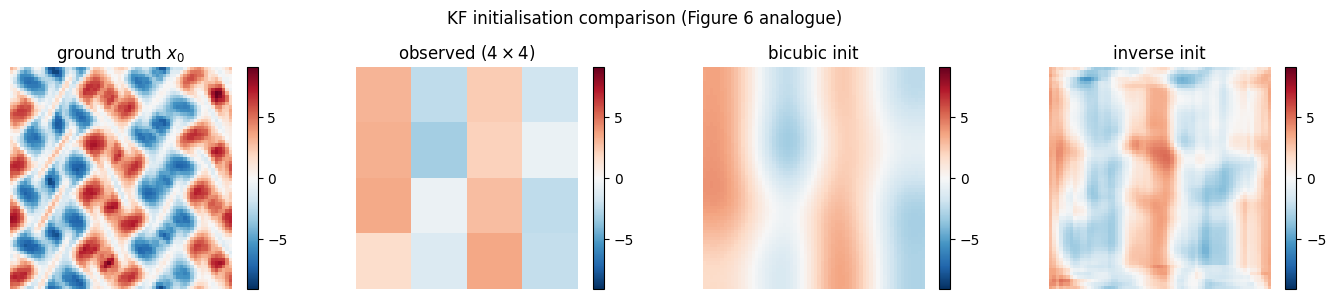

In [19]:
def baseline_init_kf(Y):
    """
    Bicubic upsample of t=0 observations to full grid.
    Y: (N, T, Ho, Wo) or (T, Ho, Wo). Returns (N, H, W) or (H, W).
    """
    squeeze = Y.ndim == 3
    if squeeze:
        Y = Y.unsqueeze(0)           # add batch dim
    y0 = Y[:, 0].unsqueeze(1)       # (N, 1, Ho, Wo)  — take t=0
    up = F.interpolate(y0, size=(64, 64), mode='bicubic', align_corners=False)
    up = up.squeeze(1)               # (N, 64, 64)
    return up.squeeze(0) if squeeze else up


def invobs_init_kf(inverter, Y):
    """
    Use the trained inverse network: map observation sequence to physical trajectory,
    return the t=0 frame as the initial condition.
    Y: (N, T, Ho, Wo). Returns (N, H, W).
    """
    with torch.no_grad():
        pred = inverter(Y)          # (N, T, 64, 64)
    return pred[:, 0]               # (N, 64, 64)  — t=0 frame


# Quick visual comparison on one test sample
_, X_vis, Y_vis, _ = generate_data_kf(KF_PAPER, n_samples=1,
                                       n_time_steps=T_TRAIN_KF,
                                       n_warmup_inner=750, seed=777)
x0_true  = X_vis[0, 0]                  #was 300 before^ # (64, 64)
x0_bic   = baseline_init_kf(Y_vis)[0]                    # (64, 64)
x0_inv   = invobs_init_kf(kf_inv, Y_vis)[0]              # (64, 64)
y0_obs   = Y_vis[0, 0]                                   # (4, 4)

vmax = x0_true.abs().max().item()
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
titles = ['ground truth $x_0$', 'observed ($4\\times4$)',
          'bicubic init', 'inverse init']
imgs   = [x0_true, y0_obs, x0_bic, x0_inv]
for ax, img, title in zip(axes, imgs, titles):
    im = ax.imshow(img.cpu(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('KF initialisation comparison (Figure 6 analogue)')
plt.tight_layout(); plt.show()

### 4.7 Variational DA for KF

The cost function mirrors the L96 formulation but operates on 2-D fields.  
We flatten the $64\times64$ state to a 4096-dimensional vector for L-BFGS,  
using the diagonal preconditioning $z_k = x_k / \sigma_k$ (per-pixel whitening).

In [20]:
def kf_decorrelate(omega, std):
    """Per-pixel normalise: z = omega / sigma.  omega: (..., H, W)."""
    return omega / std


def kf_correlate(z, std):
    """Reverse: omega = z * sigma."""
    return z * std


def da_loss_kf(z0_flat, Y, kf, std, T, mode, inverter=None):
    """
    DA loss for KF.
    z0_flat : (H*W,)   decorrelated + flattened initial state
    Y       : (T, Ho, Wo) observations for one sample
    mode    : 'obs' | 'physics'
    """
    N   = kf.N
    z0  = z0_flat.reshape(N, N)
    x0  = kf_correlate(z0, std)                      # (64, 64)
    traj = kf.integrate(x0, T)                       # (T, 64, 64)

    if mode == 'obs':
        pred   = kf.observe(traj)                    # (T, Ho, Wo)
        target = Y
        return ((pred - target) ** 2).mean()
    elif mode == 'physics':
        assert inverter is not None
        with torch.no_grad():
            inv = inverter(Y.unsqueeze(0)).squeeze(0).detach()  # (T, 64, 64)
        return ((traj - inv) ** 2).mean()
    else:
        raise ValueError(mode)


def run_da_kf(kf, inverter, kf_corr, omega0_init, Y_single, T,
              physics_steps=0, obs_steps=500):
    """
    Single-sample KF DA.
    omega0_init : (64, 64)   initial state guess
    Y_single    : (T, Ho, Wo) observations
    Returns omega0_opt (64, 64) and loss history.
    """
    std = kf_corr['std']    # (64, 64)
    z0  = kf_decorrelate(omega0_init, std).flatten()   # (4096,)
    hist = []

    if physics_steps > 0:
        loss_p = partial(da_loss_kf, Y=Y_single, kf=kf, std=std, T=T,
                         mode='physics', inverter=inverter)
        z0, h1 = lbfgs_minimize(loss_p, z0, max_iter=physics_steps)
        hist.extend(h1)

    if obs_steps > 0:
        loss_o = partial(da_loss_kf, Y=Y_single, kf=kf, std=std, T=T, mode='obs')
        z0, h2 = lbfgs_minimize(loss_o, z0, max_iter=obs_steps)
        hist.extend(h2)

    omega0_opt = kf_correlate(z0.reshape(kf.N, kf.N), std)
    return omega0_opt.detach(), hist


print('KF DA functions defined.')

KF DA functions defined.


### 4.8 Error metric — mean relative $L_1$ error

The paper uses $\varepsilon(z_1, z_2) = \|z_1 - z_2\|_1 / \gamma$  
where $\gamma$ is the mean $L_1$ distance between independent random states  
drawn from the stationary distribution (equation 5).  
An error of 1 means *no better than guessing a random state*.

In [21]:
def estimate_gamma_kf(kf, n_samples=200, n_warmup_inner=750, seed=50):
    """
    Estimate gamma = E[||z1 - z2||_1] for random independent states z1, z2
    from the stationary distribution. Used to normalise the L1 forecast error.
    """
    g = torch.Generator(device=device).manual_seed(seed)
    omega0 = torch.randn(n_samples, kf.N, kf.N, device=device, generator=g) * 0.5
    warmed = torch.stack([kf.warmup(o, n_warmup_inner) for o in omega0], dim=0)
    # Pair up samples and compute mean L1 distance
    half = n_samples // 2
    diff = (warmed[:half] - warmed[half:]).abs().mean(dim=(-2, -1))  # (half,)
    return diff.mean().item()


gamma_kf = estimate_gamma_kf(KF_PAPER, n_samples=200, n_warmup_inner=750)
print(f'gamma_kf = {gamma_kf:.4f}  (normalisation constant for L1 error)')


def l1_relative_error_kf(pred, truth, gamma):
    """
    pred, truth: (H, W) vorticity fields.
    Returns scalar relative L1 error.
    """
    return (pred - truth).abs().mean().item() / gamma

gamma_kf = 4.9396  (normalisation constant for L1 error)


### 4.9 DA experiment — four method combinations

We compare the same four combinations as in the L96 experiment  
(Figure 7 in the paper), on a small evaluation set.

In [22]:
N_EVAL_KF   = 8    # paper: 100  (increase for more reliable statistics)
T_EVAL_KF   = 10
SIGMA_OBS_KF = 0.0  # noiseless, matching the paper's KF experiment

KF_COMBOS = {
    'baseline + obs':          dict(init='baseline', p_steps=0,   o_steps=1000),
    'baseline + hybrid':       dict(init='baseline', p_steps=100, o_steps=900),
    'invobs + obs':            dict(init='invobs',   p_steps=0,   o_steps=1000),
    'invobs + hybrid (paper)': dict(init='invobs',   p_steps=100, o_steps=900),
}

cache_key_kf = f'kf_da_results_N{N_EVAL_KF}_T{T_EVAL_KF}.pt'
cached_kf = load_cache(cache_key_kf)

if cached_kf is None:
    # Generate evaluation trajectories
    omega0_gt, X_eval, Y_eval, _ = generate_data_kf(
        KF_PAPER, n_samples=N_EVAL_KF, n_time_steps=T_EVAL_KF,
        n_warmup_inner=750, obs_noise_std=SIGMA_OBS_KF, seed=400)

    kf_results = {name: [] for name in KF_COMBOS}
    kf_recovered = {name: [] for name in KF_COMBOS}

    for sample_idx in range(N_EVAL_KF):
        omega_true = omega0_gt[sample_idx]          # (64, 64)
        y_single   = Y_eval[sample_idx]             # (T, 4, 4)
        Y_batch    = y_single.unsqueeze(0)          # (1, T, 4, 4)

        omega_bic = baseline_init_kf(Y_batch)[0]   # (64, 64)
        omega_inv = invobs_init_kf(kf_inv, Y_batch)[0]

        for name, cfg in KF_COMBOS.items():
            init = omega_bic if cfg['init'] == 'baseline' else omega_inv
            import time; t0 = time.time()
            omega_opt, _ = run_da_kf(KF_PAPER, kf_inv, kf_corr,
                                     init, y_single, T_EVAL_KF,
                                     physics_steps=cfg['p_steps'],
                                     obs_steps=cfg['o_steps'])
            err = l1_relative_error_kf(omega_opt, omega_true, gamma_kf)
            kf_results[name].append(err)
            kf_recovered[name].append(omega_opt.cpu())
            print(f'  sample {sample_idx}  {name:28s}  L1_rel={err:.4f}  ({time.time()-t0:.1f}s)')

    save_cache({'results': kf_results, 'recovered': kf_recovered,
                'omega0_gt': omega0_gt, 'X_eval': X_eval, 'Y_eval': Y_eval},
               cache_key_kf)
else:
    kf_results   = cached_kf['results']
    kf_recovered = cached_kf['recovered']
    omega0_gt    = cached_kf['omega0_gt']
    X_eval       = cached_kf['X_eval']
    Y_eval       = cached_kf['Y_eval']
    print('Loaded KF DA results from cache.')

# Print summary
print('\n=== KF DA results (mean ± std relative L1 error) ===')
for name, errs in kf_results.items():
    arr = np.array(errs)
    print(f'  {name:28s}  {arr.mean():.4f} ± {arr.std():.4f}')

  [cache] loaded kf_da_results_N8_T10.pt
Loaded KF DA results from cache.

=== KF DA results (mean ± std relative L1 error) ===
  baseline + obs                1.0848 ± 0.2010
  baseline + hybrid             0.7707 ± 0.1485
  invobs + obs                  0.7198 ± 0.1311
  invobs + hybrid (paper)       0.7857 ± 0.1546


### 4.10 Results — bar chart (Table 3 analogue)

Mean relative $L_1$ error for each method combination.  
Lower is better. Values below 1 indicate improvement over random guessing.

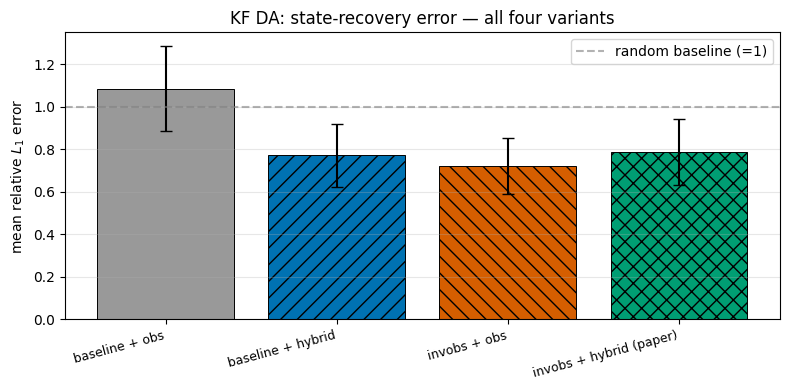

In [23]:
cb_colors_kf  = ['#999999', '#0072B2', '#D55E00', '#009E73']
cb_hatches_kf = ['', '//', '\\\\', 'xx']

fig, ax = plt.subplots(figsize=(8, 4))
names  = list(KF_COMBOS.keys())
means  = [np.array(kf_results[n]).mean() for n in names]
stds   = [np.array(kf_results[n]).std()  for n in names]

bars = ax.bar(range(len(names)), means, yerr=stds, capsize=4,
              color=cb_colors_kf, hatch=cb_hatches_kf,
              edgecolor='black', linewidth=0.7)
ax.axhline(1.0, ls='--', color='gray', alpha=0.6, label='random baseline (=1)')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('mean relative $L_1$ error')
ax.set_title('KF DA: state-recovery error — all four variants')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.11 Vorticity snapshot comparison (Figure 6/9 analogue)

Visual comparison of ground truth, bicubic initialisation, inverse initialisation,  
and the DA-recovered state for one test sample.

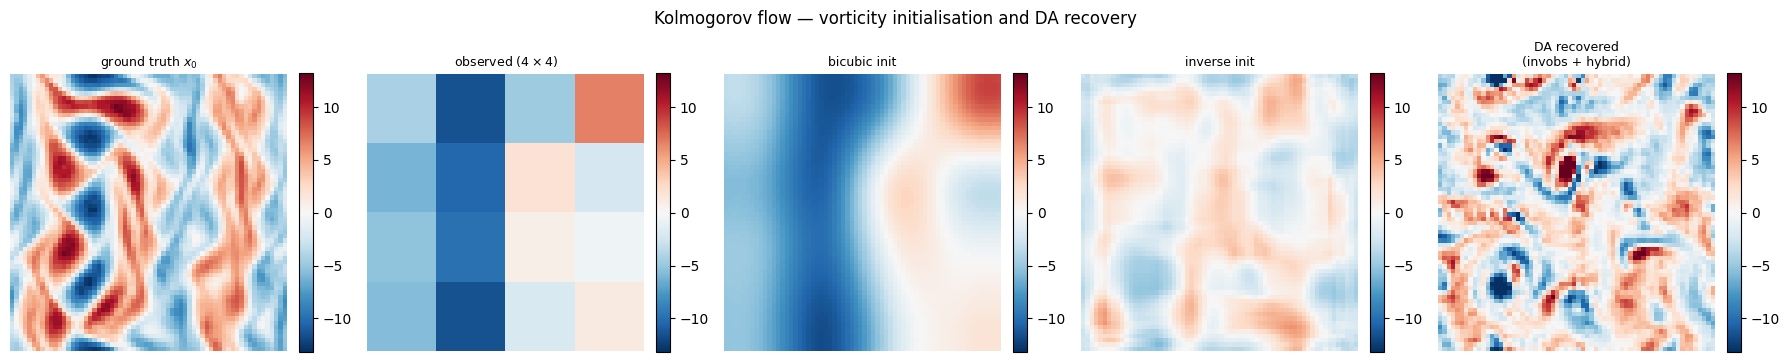

In [24]:
sample_vis = 0
omega_true_vis = omega0_gt[sample_vis].cpu().numpy()      # (64, 64)
y_vis          = Y_eval[sample_vis, 0].cpu().numpy()      # (4, 4)  t=0 obs

omega_bic_vis  = baseline_init_kf(Y_eval[sample_vis:sample_vis+1])[0].cpu().numpy()
omega_inv_vis  = invobs_init_kf(kf_inv, Y_eval[sample_vis:sample_vis+1])[0].cpu().numpy()
omega_da_best  = kf_recovered['invobs + hybrid (paper)'][sample_vis].cpu().numpy()

vmax = np.abs(omega_true_vis).max()
titles = ['ground truth $x_0$',
          f'observed ($4\\times4$)',
          'bicubic init',
          'inverse init',
          'DA recovered\n(invobs + hybrid)']
imgs   = [omega_true_vis, y_vis, omega_bic_vis, omega_inv_vis, omega_da_best]

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, img, title in zip(axes, imgs, titles):
    im = ax.imshow(img, cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax,
                   interpolation='nearest')
    ax.set_title(title, fontsize=9); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle('Kolmogorov flow — vorticity initialisation and DA recovery', y=1.02)
plt.tight_layout()
plt.show()

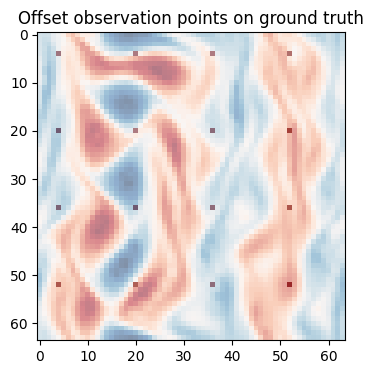

In [25]:
# Quick check — visualize new observation locations
mask = torch.zeros(64, 64)
mask[4::16, 4::16] = 1.0

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(omega_true_vis, cmap='RdBu_r')
ax.imshow(mask.numpy(), cmap='Reds', alpha=0.5)
ax.set_title('Offset observation points on ground truth')
plt.show()

### 4.12 Forecast skill — relative $L_1$ error vs lead time

Integrate each recovered $x_0$ forward and measure how quickly the  
forecast diverges from the ground truth (Figure 7 analogue).

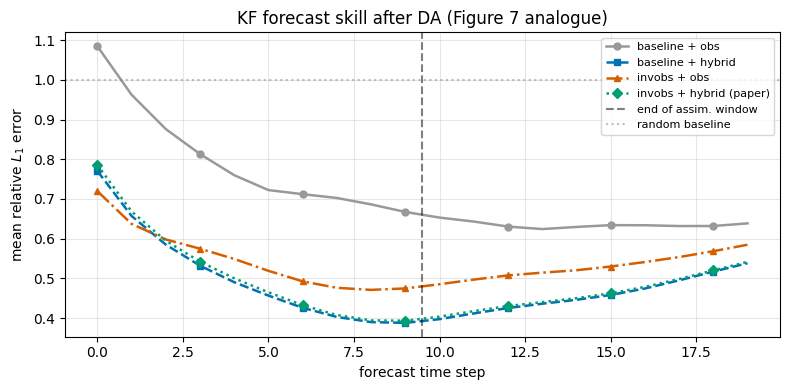

In [27]:
T_FC_KF = 20   # forecast steps beyond the assimilation window

fig, ax = plt.subplots(figsize=(8, 4))

for i, (name, cfg) in enumerate(KF_COMBOS.items()):
    errors_t = []
    for sample_idx in range(N_EVAL_KF):
        omega_true_traj = KF_PAPER.integrate(omega0_gt[sample_idx], T_FC_KF)  # (T_FC, 64, 64)
        omega_rec = kf_recovered[name][sample_idx].to(device)
        omega_rec_traj = KF_PAPER.integrate(omega_rec, T_FC_KF)               # (T_FC, 64, 64)
        err_t = [(omega_rec_traj[t] - omega_true_traj[t]).abs().mean().item() / gamma_kf
                 for t in range(T_FC_KF)]
        errors_t.append(err_t)
    mean_err = np.array(errors_t).mean(axis=0)
    ax.plot(mean_err, color=cb_colors_kf[i], linestyle=['-','--','-.',':'][i],
            marker=['o','s','^','D'][i], markevery=3, markersize=5,
            lw=1.8, label=name)

ax.axvline(T_EVAL_KF - 0.5, ls='--', color='k', alpha=0.5, label='end of assim. window')
ax.axhline(1.0, ls=':', color='gray', alpha=0.5, label='random baseline')
ax.set_xlabel('forecast time step')
ax.set_ylabel('mean relative $L_1$ error')
ax.set_title('KF forecast skill after DA (Figure 7 analogue)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.13 Summary table (Table 3 analogue)

Mean relative $L_1$ error at the **first forecast state** ($t=T$, just after  
the assimilation window ends), expressed relative to the baseline obs-only method.  
Values below 1 indicate improvement over the baseline.

In [28]:
print('\n=== Table 3 analogue: mean relative L1 at t=T ===')
print(f'{"Method":30s}  {"Abs. L1":>10s}  {"Rel. to baseline":>18s}')
print('-' * 62)

baseline_err = np.array(kf_results['baseline + obs']).mean()
for name, errs in kf_results.items():
    abs_err = np.array(errs).mean()
    rel_err = abs_err / baseline_err
    bold = ' <-- best' if rel_err == min(
        np.array(v).mean() / baseline_err for v in kf_results.values()) else ''
    print(f'{name:30s}  {abs_err:10.4f}  {rel_err:18.4f}{bold}')


=== Table 3 analogue: mean relative L1 at t=T ===
Method                             Abs. L1    Rel. to baseline
--------------------------------------------------------------
baseline + obs                      1.0848              1.0000
baseline + hybrid                   0.7707              0.7105
invobs + obs                        0.7198              0.6636 <-- best
invobs + hybrid (paper)             0.7857              0.7243


### 4.14 Next steps and known limitations

**Known limitations of this implementation:**
- **Undertrained network** — 60 epochs vs paper's 500; loss likely still declining.
- **Small evaluation set** — 8 samples vs paper's 100; error bars are wide.
- **Diagonal whitening** — full spatial covariance is approximated; a proper  
  ensemble-estimated $B$ would improve the background term.
- **No gradient checkpointing** — backprop through long KF integrations is  
  memory-intensive; add `torch.utils.checkpoint` inside `integrate` if you  
  hit out-of-memory errors on long windows.

**Extensions to try:**
1. Increase `N_TRAIN_KF` and `N_EPOCHS_KF` toward paper values.
2. Add observation noise ($\sigma_{obs} > 0$) and retrain a matched inverter.
3. Implement gradient checkpointing for longer assimilation windows.
4. Add the combined cost function:  
   $J = J_{4D\text{-}Var} + \lambda \|M(x_0) - h_\theta(y)\|^2$  
   to combine the learned prior with the classical variational term.

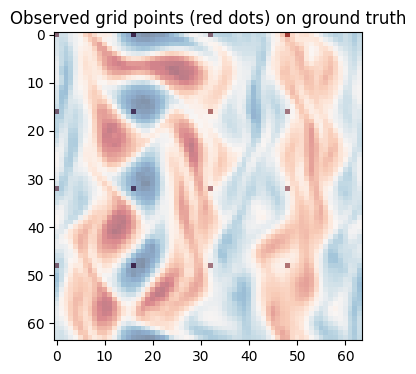

In [29]:
mask = torch.zeros(64, 64)
mask[::KF_PAPER.observe_every, ::KF_PAPER.observe_every] = 1.0

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(omega_true_vis, cmap='RdBu_r')
ax.imshow(mask.numpy(), cmap='Reds', alpha=0.5)
ax.set_title('Observed grid points (red dots) on ground truth')
plt.show()